<a href="https://colab.research.google.com/github/loki-gif/case_study/blob/main/home_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [132]:
import numpy as np
import pandas as pd

In [133]:
house = pd.read_csv('/content/House_Pricing.csv')
house

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [134]:
house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [135]:
house.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [136]:
house.corr(numeric_only = True)

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
ID,1.000000,-0.016834,0.001286,0.005186,-0.012384,-0.132110,0.018525,0.013799,-0.010738,-0.005151,-0.021380,-0.016907,-0.008269,-0.001952,0.020805,-0.002888,-0.138798
Sale Price,-0.016834,1.000000,0.308463,0.525124,0.702081,0.089616,0.256941,0.580654,0.605495,0.323813,-0.054034,0.126436,-0.053198,0.306889,0.021507,0.585393,0.082445
No of Bedrooms,0.001286,0.308463,1.000000,0.515883,0.576616,0.031620,0.175429,0.349008,0.477592,0.303093,-0.154178,0.018841,-0.152656,-0.008879,0.129499,0.391649,0.029244
No of Bathrooms,0.005186,0.525124,0.515883,1.000000,0.754691,0.087758,0.500601,0.635573,0.685249,0.283774,-0.505957,0.050752,-0.204044,0.024508,0.223165,0.568606,0.087218
Flat Area (in Sqft),-0.012384,0.702081,0.576616,0.754691,1.000000,0.172809,0.353950,0.705835,0.876587,0.435230,-0.318207,0.055365,-0.199416,0.052543,0.240152,0.756357,0.183223
Lot Area (in Sqft),-0.132110,0.089616,0.031620,0.087758,0.172809,1.000000,-0.005235,0.102345,0.183512,0.015287,-0.053062,0.007717,-0.129536,-0.085672,0.229494,0.144548,0.718548
No of Floors,0.018525,0.256941,0.175429,0.500601,0.353950,-0.005235,1.000000,0.461228,0.523840,-0.245705,-0.489319,0.006338,-0.059122,0.049648,0.125391,0.279874,-0.011269
Overall Grade,0.013799,0.580654,0.349008,0.635573,0.705835,0.102345,0.461228,1.000000,0.705183,0.145266,-0.456629,0.010440,-0.185836,0.111301,0.201745,0.681338,0.107581
Area of the House from Basement (in Sqft),-0.010738,0.605495,0.477592,0.685249,0.876587,0.183512,0.523840,0.705183,1.000000,-0.051821,-0.423822,0.023301,-0.261130,-0.000866,0.343776,0.731998,0.194100
Basement Area (in Sqft),-0.005151,0.323813,0.303093,0.283774,0.435230,0.015287,-0.245705,0.145266,-0.051821,1.000000,0.133124,0.071323,0.074854,0.110554,-0.144728,0.200371,0.017276


In [137]:
house['Date House was Sold'] = pd.to_datetime(house['Date House was Sold'])
house.drop_duplicates(inplace = True)
house.drop(columns = ['Area of the House from Basement (in Sqft)','ID'],inplace = True)

In [138]:
house.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489
Condition of the House,0


The rows with 'Sale Price missing was dropped because 'SalePrice' was the target.


Since 'No of Times Visited' column has a large number of missing values it is better to drop that column.

All other missing values were filled with median of the respective column

In [139]:
house.dropna(subset = ['Sale Price'],inplace = True)
house.drop(columns = ['No of Times Visited'],inplace  =True)
columns = ['No of Bathrooms','Flat Area (in Sqft)','Lot Area (in Sqft)','Latitude','Longitude','Zipcode','Living Area after Renovation (in Sqft)']
for i in columns :
  house[i] = house[i].fillna(house[i].median())


In [140]:
house.isna().sum()

,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


In [141]:
outlier_cols = [
    "No of Bedrooms",
    "No of Bathrooms",
    "Flat Area (in Sqft)",
    "Lot Area (in Sqft)",
    "Basement Area (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "Lot Area after Renovation (in Sqft)"
]
for col in outlier_cols:
    Q1 = house[col].quantile(0.25)
    Q3 = house[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    house[col] = house[col].clip(lower=lower, upper=upper)




array([[<Axes: title={'center': 'Sale Price'}>,
        <Axes: title={'center': 'No of Bedrooms'}>,
        <Axes: title={'center': 'No of Bathrooms'}>,
        <Axes: title={'center': 'Flat Area (in Sqft)'}>],
       [<Axes: title={'center': 'Lot Area (in Sqft)'}>,
        <Axes: title={'center': 'No of Floors'}>,
        <Axes: title={'center': 'Overall Grade'}>,
        <Axes: title={'center': 'Basement Area (in Sqft)'}>],
       [<Axes: title={'center': 'Age of House (in Years)'}>,
        <Axes: title={'center': 'Renovated Year'}>,
        <Axes: title={'center': 'Zipcode'}>,
        <Axes: title={'center': 'Latitude'}>],
       [<Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'Living Area after Renovation (in Sqft)'}>,
        <Axes: title={'center': 'Lot Area after Renovation (in Sqft)'}>,
        <Axes: >]], dtype=object)

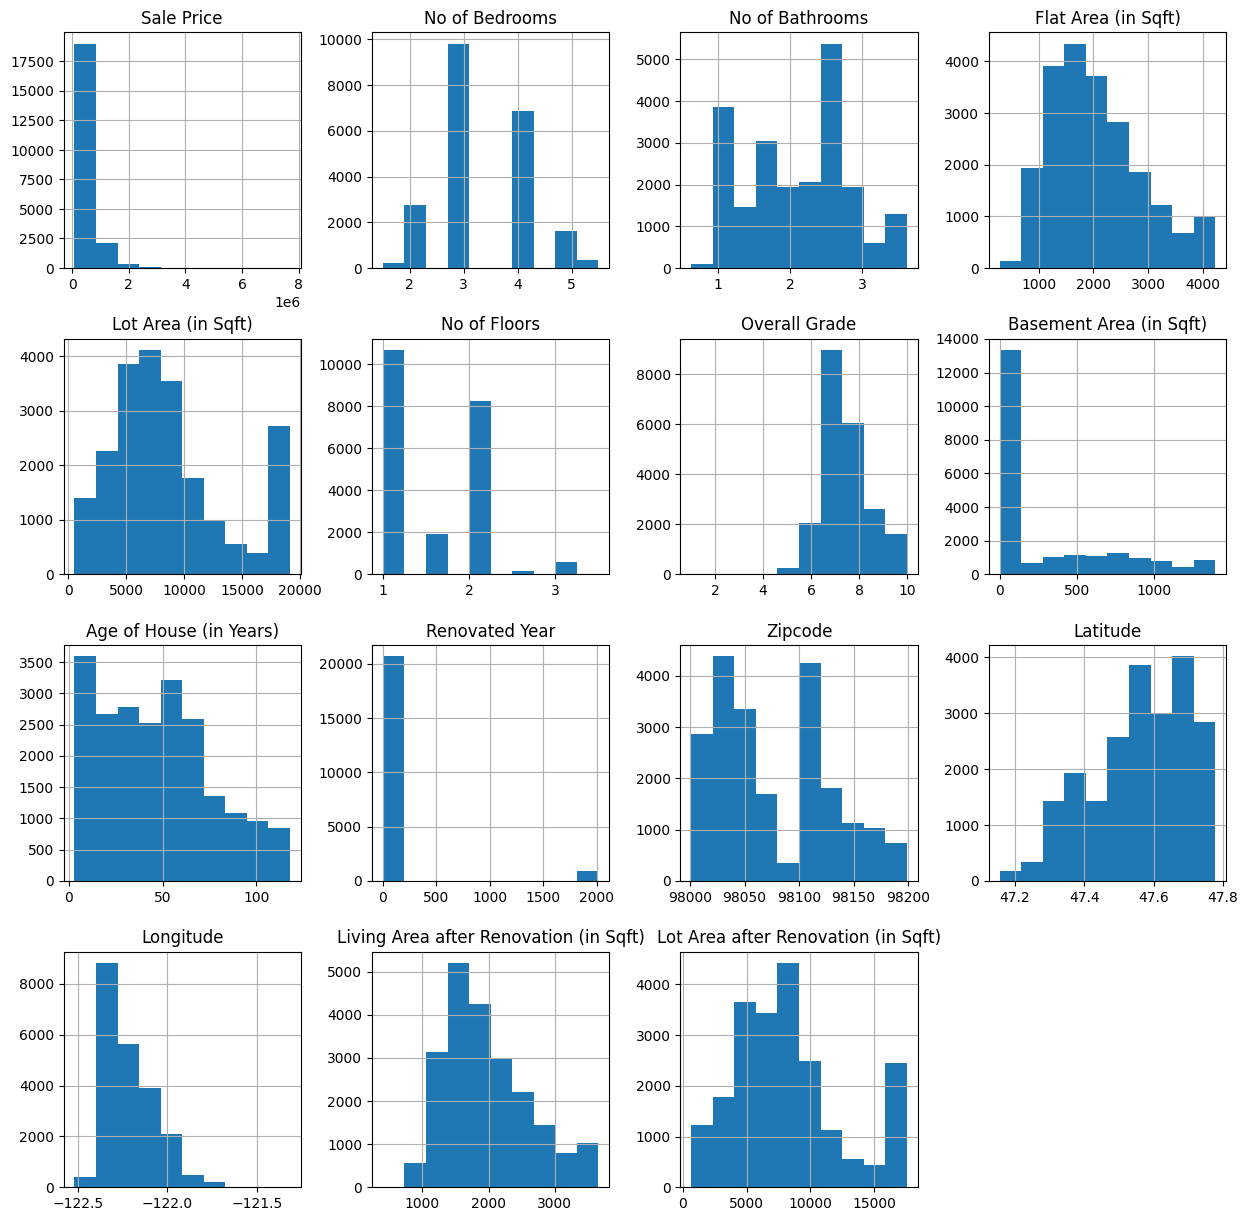

In [142]:
freqgraph = house.select_dtypes(include='number')
freqgraph.hist(figsize=(15, 15))

In [143]:
house.select_dtypes(include="number").skew().sort_values()

,0
Latitude,-0.485150
No of Bathrooms,0.043578
No of Bedrooms,0.240545
Overall Grade,0.321409
Zipcode,0.405797
Age of House (in Years),0.469648
No of Floors,0.616039
Flat Area (in Sqft),0.728184
Lot Area after Renovation (in Sqft),0.768495
Living Area after Renovation (in Sqft),0.774189


In [144]:
house

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,2017-10-14,221900.0,3.0,1.00,1180.0,5650.0,1.0,No,Fair,7,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,2017-12-14,538000.0,3.0,2.25,2570.0,7242.0,2.0,No,Fair,7,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,2016-02-15,180000.0,2.0,1.00,770.0,10000.0,1.0,No,Fair,6,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2017-12-14,604000.0,4.0,3.00,1960.0,5000.0,1.0,No,Excellent,7,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,2016-02-15,510000.0,3.0,2.00,1680.0,8080.0,1.0,No,Fair,8,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,2017-05-14,360000.0,3.0,2.50,1530.0,1131.0,3.0,No,Fair,8,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,2016-02-15,400000.0,4.0,2.50,2310.0,5813.0,2.0,No,Fair,8,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,2017-06-14,402101.0,2.0,0.75,1020.0,1350.0,2.0,No,Fair,7,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,2016-01-15,400000.0,3.0,2.50,1600.0,2388.0,2.0,No,Fair,8,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [145]:
house.select_dtypes(include="object").columns

Index(['Waterfront View', 'Condition of the House'], dtype='object')

In [146]:
house['Condition of the House'].value_counts()

,count
Condition of the House,
Fair,14028
Good,5678
Excellent,1701
Okay,172
Bad,30


In [147]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
house['Waterfront View'] = label.fit_transform(house['Waterfront View'])

In [148]:
condition_map = {
    'Bad' : 1,
    'Okay' : 2,
    'Fair' : 3,
    'Good' : 4,
    'Excellent' : 5
}

house['Condition of the House'] = house['Condition of the House'].map(condition_map)

In [149]:
house

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,2017-10-14,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,3,7,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,2017-12-14,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,3,7,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,2016-02-15,180000.0,2.0,1.00,770.0,10000.0,1.0,0,3,6,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2017-12-14,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,5,7,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,2016-02-15,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,3,8,0,31,0,98074.0,47.6168,-122.045,1800.0,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,2017-05-14,360000.0,3.0,2.50,1530.0,1131.0,3.0,0,3,8,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,2016-02-15,400000.0,4.0,2.50,2310.0,5813.0,2.0,0,3,8,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,2017-06-14,402101.0,2.0,0.75,1020.0,1350.0,2.0,0,3,7,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,2016-01-15,400000.0,3.0,2.50,1600.0,2388.0,2.0,0,3,8,0,14,0,98027.0,47.5345,-122.069,1410.0,1287


In [150]:
print(house.head())

  Date House was Sold  Sale Price  No of Bedrooms  No of Bathrooms  \
0          2017-10-14    221900.0             3.0             1.00   
1          2017-12-14    538000.0             3.0             2.25   
2          2016-02-15    180000.0             2.0             1.00   
3          2017-12-14    604000.0             4.0             3.00   
4          2016-02-15    510000.0             3.0             2.00   

   Flat Area (in Sqft)  Lot Area (in Sqft)  No of Floors  Waterfront View  \
0               1180.0              5650.0           1.0                0   
1               2570.0              7242.0           2.0                0   
2                770.0             10000.0           1.0                0   
3               1960.0              5000.0           1.0                0   
4               1680.0              8080.0           1.0                0   

   Condition of the House  Overall Grade  Basement Area (in Sqft)  \
0                       3              7       

In [151]:
house["Renovated"] = (house["Renovated Year"] > 0).astype(int)
house.drop(columns=["Renovated Year"], inplace=True)

In [152]:
house["Sale Year"] = house["Date House was Sold"].dt.year
house["Sale Month"] = house["Date House was Sold"].dt.month

house.drop(columns=["Date House was Sold"], inplace=True)

In [153]:
house

,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Renovated,Sale Year,Sale Month
0,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,3,7,0,63,98178.0,47.5112,-122.257,1340.0,5650,0,2017,10
1,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,3,7,400,67,98125.0,47.7210,-122.319,1690.0,7639,1,2017,12
2,180000.0,2.0,1.00,770.0,10000.0,1.0,0,3,6,0,85,98028.0,47.7379,-122.233,2720.0,8062,0,2016,2
3,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,5,7,910,53,98136.0,47.5208,-122.393,1360.0,5000,0,2017,12
4,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,3,8,0,31,98074.0,47.6168,-122.045,1800.0,7503,0,2016,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3.0,2.50,1530.0,1131.0,3.0,0,3,8,0,9,98103.0,47.6993,-122.346,1530.0,1509,0,2017,5
21609,400000.0,4.0,2.50,2310.0,5813.0,2.0,0,3,8,0,4,98146.0,47.5107,-122.362,1830.0,7200,0,2016,2
21610,402101.0,2.0,0.75,1020.0,1350.0,2.0,0,3,7,0,9,98144.0,47.5944,-122.299,1020.0,2007,0,2017,6
21611,400000.0,3.0,2.50,1600.0,2388.0,2.0,0,3,8,0,14,98027.0,47.5345,-122.069,1410.0,1287,0,2016,1


In [154]:
house.info()
house.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 21609 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Sale Price                              21609 non-null  float64
 1   No of Bedrooms                          21609 non-null  float64
 2   No of Bathrooms                         21609 non-null  float64
 3   Flat Area (in Sqft)                     21609 non-null  float64
 4   Lot Area (in Sqft)                      21609 non-null  float64
 5   No of Floors                            21609 non-null  float64
 6   Waterfront View                         21609 non-null  int64  
 7   Condition of the House                  21609 non-null  int64  
 8   Overall Grade                           21609 non-null  int64  
 9   Basement Area (in Sqft)                 21609 non-null  int64  
 10  Age of House (in Years)                 21609 non-null  int64  

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0
Basement Area (in Sqft),0


In [155]:
y = house['Sale Price']
x = house.drop(columns = ['Sale Price'])

In [156]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [157]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
skewed_cols = [
    "Flat Area (in Sqft)",
    "Lot Area (in Sqft)",
    "Basement Area (in Sqft)",
    "Living Area after Renovation (in Sqft)",
    "Lot Area after Renovation (in Sqft)"

]
x_train[skewed_cols] = np.log1p(x_train[skewed_cols])
x_test[skewed_cols] = np.log1p(x_test[skewed_cols])
std = StandardScaler()
x_train[skewed_cols] = std.fit_transform(x_train[skewed_cols])
x_test[skewed_cols] = std.transform(x_test[skewed_cols])
location_cols = ["Longitude", "Latitude"]
x_train[location_cols] = std.fit_transform(x_train[location_cols])
x_test[location_cols] = std.transform(x_test[location_cols])

In [158]:
minmax_cols = [
    "Overall Grade",
    "Age of House (in Years)"
]

minmax = MinMaxScaler()
x_train[minmax_cols] = minmax.fit_transform(x_train[minmax_cols])
x_test[minmax_cols] = minmax.transform(x_test[minmax_cols])

In [159]:
x_train.head()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Renovated,Sale Year,Sale Month
7095,3.0,2.50,0.176933,0.232466,2.0,0,4,0.875,-0.792614,0.347826,98008.0,0.482683,0.850246,0.839705,0.223380,0,2017,5
18538,3.0,1.00,-1.029868,-0.036483,1.0,0,3,0.625,0.774985,0.791304,98116.0,0.083768,-1.249282,-0.926208,-0.316298,0,2017,10
20023,3.0,2.25,-0.582614,-1.404910,2.0,0,3,0.625,-0.792614,0.026087,98002.0,-1.547962,-0.018034,-0.728661,-1.406656,0,2017,6
6254,5.0,3.25,1.362128,0.683166,2.0,0,4,0.750,1.340676,0.139130,98042.0,-1.225511,0.430340,0.683217,0.270715,0,2017,7
15383,4.0,2.50,0.264332,-0.248994,2.0,0,3,0.750,-0.792614,0.104348,98042.0,-1.494580,0.480159,0.096340,0.206539,0,2017,7


In [160]:
x_test.head()

,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,Condition of the House,Overall Grade,Basement Area (in Sqft),Age of House (in Years),Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Renovated,Sale Year,Sale Month
4984,4.0,2.50,0.809927,0.744870,2.0,0,3,0.750,-0.792614,0.139130,98019.0,1.245888,1.754110,0.775454,0.847834,0,2016,5
10256,3.0,2.50,-0.667017,-1.777371,1.5,0,4,0.625,-0.792614,0.913043,98103.0,0.720013,-0.829377,-0.226553,-0.835649,0,2017,8
4046,3.0,2.00,-0.735348,-0.270824,2.0,0,3,0.750,-0.792614,0.086957,98022.0,-2.514592,1.597535,-1.222206,-0.403467,0,2017,11
21269,5.0,2.75,0.590317,-0.544747,1.0,0,3,0.625,1.395845,0.060870,98118.0,-0.219927,-0.423705,-0.507420,-0.575274,0,2017,5
10496,4.0,1.75,0.165036,-0.272074,1.0,0,3,0.625,1.106069,0.486957,98144.0,0.120558,-0.622982,-0.002060,-0.945738,0,2017,9


In [161]:
y_train.head()

,Sale Price
7095,700000.0
18538,410000.0
20023,240000.0
6254,409124.0
15383,330000.0


In [162]:
y_test.head()

,Sale Price
4984,570000.0
10256,720001.0
4046,267000.0
21269,365000.0
10496,397000.0
